## DS 5030 Understanding Uncertainty Lab 1 - initial_analysis.ipynb ##
**By Fiona St. Clair**

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**1. Load the Foreign Gifts data.** 

In [87]:
gifts = pd.read_csv("ForeignGifts_edu.csv")
gifts.head()


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


 **2. Describe the differences between different classes of gift types.**

In [88]:
gifttype_col = "Gift Type"
amount_col = "Foreign Gift Amount"

display(gifts[gifttype_col].value_counts()) # number of gifts per gift type

display(gifts.groupby(gifttype_col)[amount_col].describe()) # amount grouped by gift type

display(gifts.groupby(gifttype_col)[amount_col].sum().sort_values(ascending=False)) # total amount grouped by gift type



Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Gift Type,,,,,,,,
Contract,17274.0,6.257945e+05,3.768217e+06,-537770.0,13757.5,110000.0,366000.0,99999999.0
Monetary Gift,10936.0,5.281504e+05,2.086487e+06,1.0,250.0,50000.0,400000.0,48842186.0
Real Estate,11.0,1.335265e+06,1.412071e+06,39456.0,370574.5,667555.0,2121736.0,4312000.0


Gift Type
Contract         10809974431
Monetary Gift     5775853163
Real Estate         14687920
Name: Foreign Gift Amount, dtype: int64

There are by far more contract and monetary gifts then there are real estate gifts (only 11). Contracts lead in first place with just over 17,000 and monetary takes second with nearly 11,000. Contracts generate the most value by far, however, nearly $11 billion, while monetary gifts only make around $60 million, and real estate finally with $14 million. 

**3. Answer the following questions:**

In [89]:
country_col = "Country of Giftor"
institution_col = "Institution Name"

# 1. country with most money total
display(gifts.groupby(country_col)[amount_col].sum().sort_values(ascending=False).head(1))

# 2. country with most gifts by count
display(gifts[country_col].value_counts().head(1))

# 3. country with largest gifts on average
display(gifts.groupby(country_col)[amount_col].mean().sort_values(ascending=False).head(1))

# 4. institution receiving most money total
display(gifts.groupby(institution_col)[amount_col].sum().sort_values(ascending=False).head(1))

# 5. institution receiving most gifts by count
display(gifts[institution_col].value_counts().head(1))

# 6. average and median amount per university
display(gifts.groupby(institution_col)[amount_col].mean().sort_values(ascending=False))
display(gifts.groupby(institution_col)[amount_col].median().sort_values(ascending=False))

# 7. largest single flow (country -> institution)
display(gifts.groupby([country_col, institution_col])[amount_col].sum().sort_values(ascending=False).head(1))

# 8. top giftors (countries) to US institutions
display(gifts.groupby(country_col)[amount_col].sum().sort_values(ascending=False))

Country of Giftor
QATAR    2706240869
Name: Foreign Gift Amount, dtype: int64

Country of Giftor
ENGLAND    3655
Name: count, dtype: int64

Country of Giftor
BERMUDA    7.688837e+06
Name: Foreign Gift Amount, dtype: float64

Institution Name
Carnegie Mellon University    1477922504
Name: Foreign Gift Amount, dtype: int64

Institution Name
University of California, Los Angeles    3916
Name: count, dtype: int64

Institution Name
Brigham Young University - Idaho       2.270552e+07
Western International University       1.294216e+07
Whittier College                       1.207900e+07
University of Phoenix                  1.109435e+07
Curtis Institute of Music              1.000000e+07
                                           ...     
University of Alabama at Birmingham    2.983812e+04
University of California, Merced       1.520950e+04
Marquette University                   1.404990e+04
Westminster Theological Seminary       7.695829e+03
University of Jamestown                5.000000e+02
Name: Foreign Gift Amount, Length: 318, dtype: float64

Institution Name
Brigham Young University - Idaho         22794050.5
Curtis Institute of Music                10000000.0
Juilliard School (The)                    5570000.0
Indiana State University                  4291189.0
Midwestern State University               4200000.0
                                            ...    
University of Jamestown                       500.0
University of California, Merced              398.0
University of California, Los Angeles         250.0
Claremont McKenna College                     150.0
Westminster Theological Seminary              100.0
Name: Foreign Gift Amount, Length: 318, dtype: float64

Country of Giftor  Institution Name  
QATAR              Cornell University    1018473315
Name: Foreign Gift Amount, dtype: int64

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

1. Qatar gave the most money in total, $2,706,240,869.
2. England sent the most gifts by count, 3,655 gifts.
3. Bermuda highest average gift size, $7,688,837.37.
4. Carnegie Mellon University received the most money in total, $1,477,922,504.
5. UCLA received the most gifts by count, 3,916 gifts.
6. Brigham Young University has the highest mean with 2.270552e+07 and University of Jamestown has the lowest with 5.000000e+02. Brigham Young University also has the highest median with 22794050.5, but Westminster Theological Seminary has the lowest with 100.0. These differ because some universities have outliers, such as one university getting one really big gift. This will pull the average up but the median won't change much.
7. Qatar to Cornell University has the single largest country-to-institution flow of $1,018,473,315.
8. Qatar, England, China, Saudi Arabia, Bermuda are the top 5 giftors overall.

**5 cont. - plot of the top 20 institutions by the amount or number of gifts they have received**

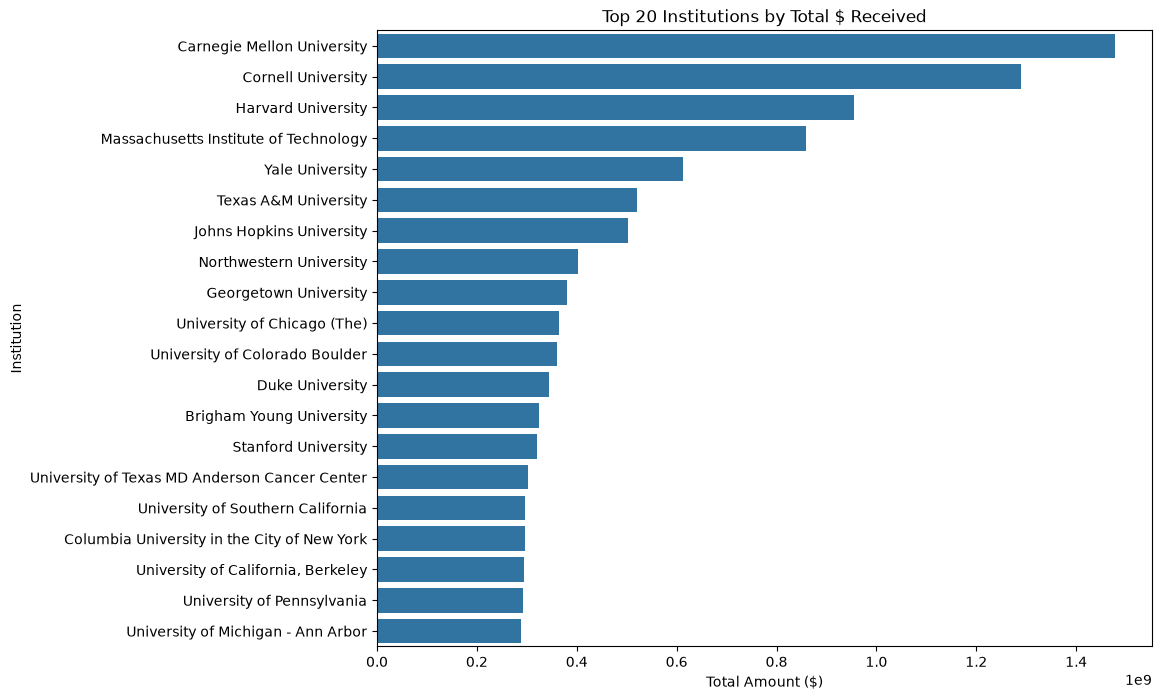

In [90]:
# top 20 institutions by total money received
top20_amount = gifts.groupby(institution_col)[amount_col].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top20_amount.values, y=top20_amount.index)
plt.xlabel("Total Amount ($)")
plt.ylabel("Institution")
plt.title("Top 20 Institutions by Total $ Received")
plt.show()

**6 cont. - histogram of the amounts received by each university, and then label the median and the mean as vertical lines**

mean amount: 588232.7172672832
median amount: 94615.0


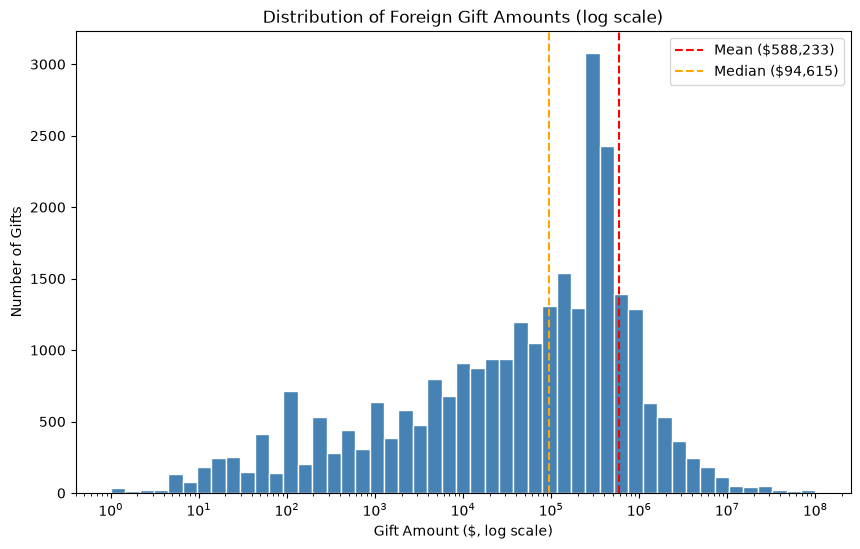

In [91]:
mean_amount = gifts[amount_col].mean()
median_amount = gifts[amount_col].median()

print("mean amount:", mean_amount)
print("median amount:", median_amount)

positive_amounts = gifts[gifts[amount_col] > 0][amount_col]

log_bins = np.geomspace(positive_amounts.min(), positive_amounts.max(), 50)

plt.figure(figsize=(10, 6))
plt.hist(positive_amounts, bins=log_bins, color="steelblue", edgecolor="white")
plt.axvline(mean_amount, color="red", linestyle="--", label=f"Mean (${mean_amount:,.0f})")
plt.axvline(median_amount, color="orange", linestyle="--", label=f"Median (${median_amount:,.0f})")
plt.xscale("log")
plt.xlabel("Gift Amount ($, log scale)")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts (log scale)")
plt.legend()
plt.show()

**7 cont. - use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions**

In [92]:
pd.crosstab(
    gifts[gifts[institution_col].isin(top20_amount.index)][country_col],
    gifts[gifts[institution_col].isin(top20_amount.index)][institution_col])

Institution Name,Brigham Young University,Carnegie Mellon University,Columbia University in the City of New York,Cornell University,Duke University,Georgetown University,Harvard University,Johns Hopkins University,Massachusetts Institute of Technology,Northwestern University,Stanford University,Texas A&M University,"University of California, Berkeley",University of Chicago (The),University of Colorado Boulder,University of Michigan - Ann Arbor,University of Pennsylvania,University of Southern California,University of Texas MD Anderson Cancer Center,Yale University
Country of Giftor,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
ARGENTINA,1,0,1,0,0,0,4,5,13,0,3,0,0,0,0,0,0,0,0,0
ARMENIA,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
AUSTRALIA,0,2,16,5,2,0,8,9,6,0,10,0,3,5,1,7,1,7,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,2,1,0,2
WALES,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0


**8 cont. - plot the flows from giftors to institutions (had to rendor in brower...extension was not loading correctly)**

In [93]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)
fig.show(renderer="browser")

AI Disclaimer: Claude Sonnet 5 was used to help me understand the code while working through this lab. It did *not* generate code for me, but helped me through understanding the different packages and tools needed for the assignment. 